In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/cclass.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/unclean cclass.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/focus.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/audi.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/toyota.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/skoda.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/ford.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/vauxhall.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/bmw.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/vw.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/hyundi.csv
/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/unclean focus.csv


# 1. Preparation

## 1.1. Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

## 1.2. Data Acquisition

In [3]:
df = pd.read_csv("/kaggle/input/datasets/adityadesai13/used-car-dataset-ford-and-mercedes/toyota.csv")

# 2. Exploratory Data Analysis (EDA)

## 2.1. Dataset Overview
### Data Shape & Columns

In [4]:
df.shape

(6738, 9)

### Data sample

In [5]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,16000,Manual,24089,Petrol,265,36.2,2.0
1,GT86,2017,15995,Manual,18615,Petrol,145,36.2,2.0
2,GT86,2015,13998,Manual,27469,Petrol,265,36.2,2.0
3,GT86,2017,18998,Manual,14736,Petrol,150,36.2,2.0
4,GT86,2017,17498,Manual,36284,Petrol,145,36.2,2.0


### Dataset Summary

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   object 
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   object 
 4   mileage       6738 non-null   int64  
 5   fuelType      6738 non-null   object 
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 473.9+ KB


No missing value.

### Descriptive Statistics

In [7]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000,6738.000000
mean,2016.748145,12522.391066,22857.413921,94.697240,63.042223,1.471297
std,2.204062,6345.017587,19125.464147,73.880776,15.836710,0.436159
min,1998.000000,850.000000,2.000000,0.000000,2.800000,0.000000
25%,2016.000000,8290.000000,9446.000000,0.000000,55.400000,1.000000
50%,2017.000000,10795.000000,18513.000000,135.000000,62.800000,1.500000
75%,2018.000000,14995.000000,31063.750000,145.000000,69.000000,1.800000
max,2020.000000,59995.000000,174419.000000,565.000000,235.000000,4.500000


In [8]:
df.describe(include='object') 

,model,transmission,fuelType
count,6738,6738,6738
unique,18,4,4
top,Yaris,Manual,Petrol
freq,2122,3826,4087


## 2.2. Target Distribution

<Axes: xlabel='price', ylabel='Count'>

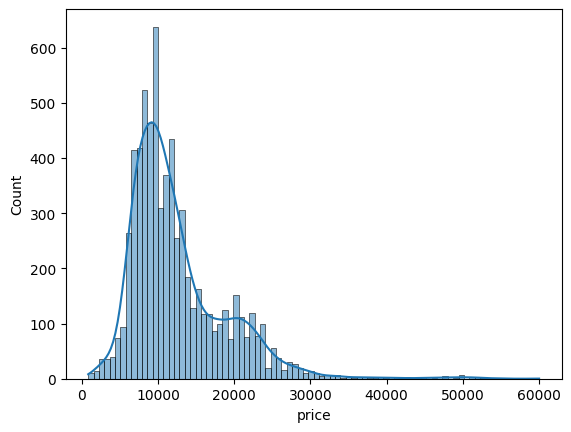

In [9]:
sns.histplot(df['price'], kde=True)

In [10]:
# Skewness & Kurtosis
print("Skewness: %f" % df['price'].skew())
print("Kurtosis: %f" % df['price'].kurt())

Skewness: 1.816743
Kurtosis: 5.810489


## 2.3. Correlation Matrix

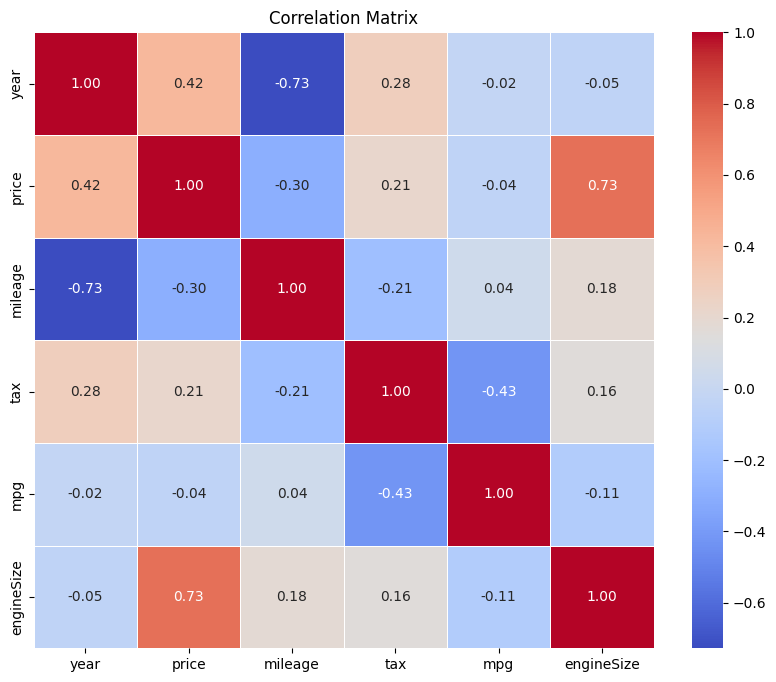

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

## 2.4. Numerical feature distribution

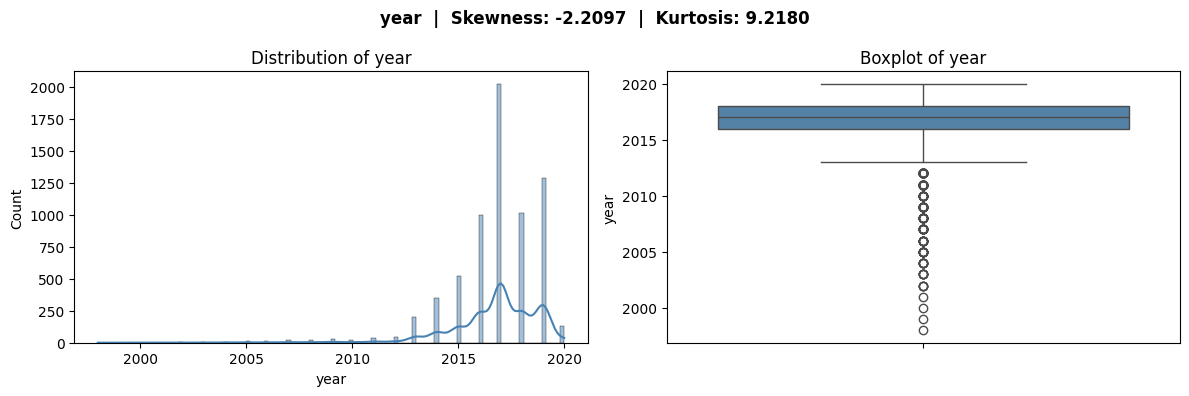

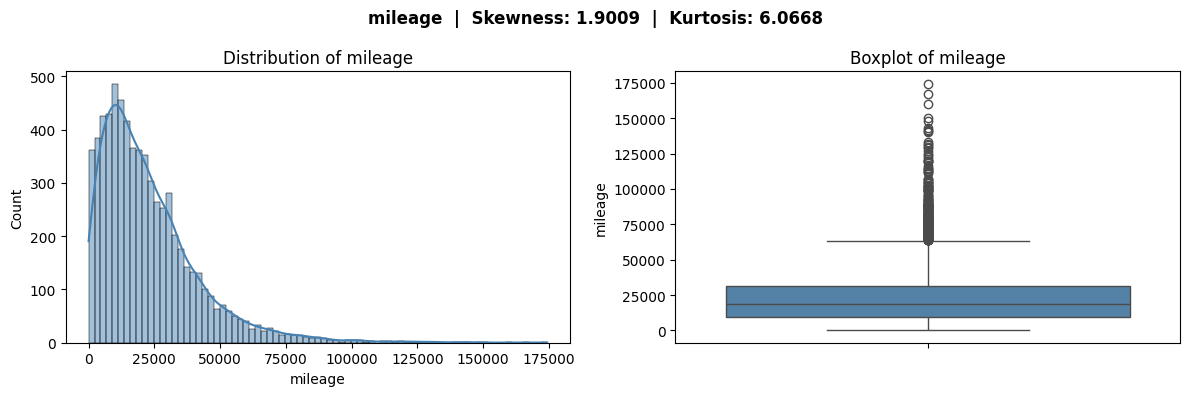

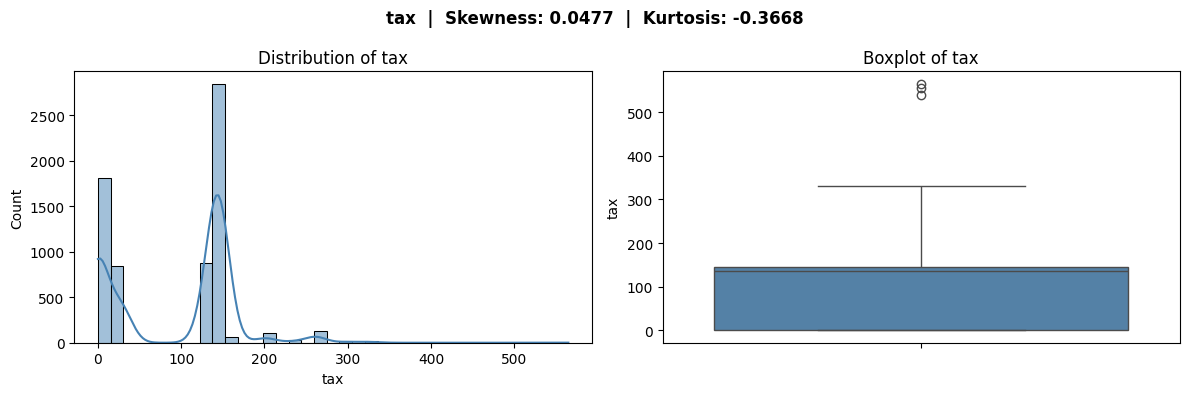

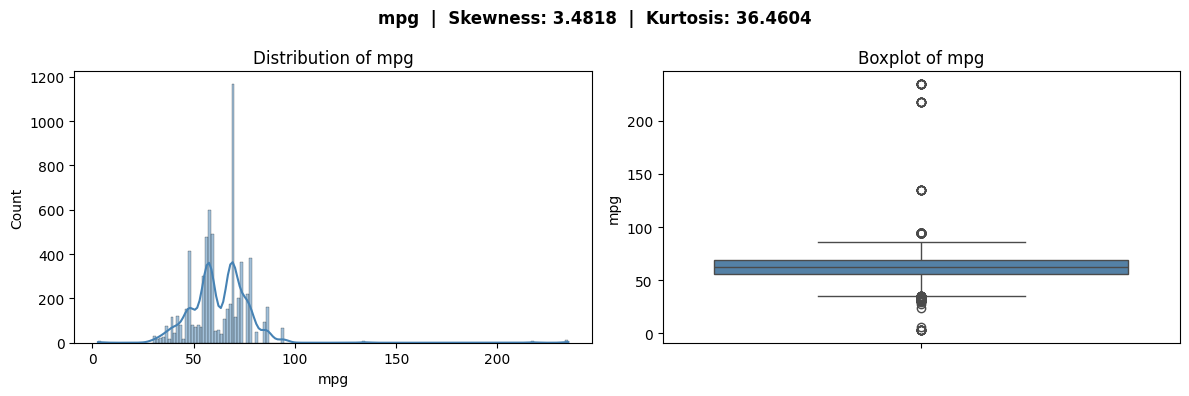

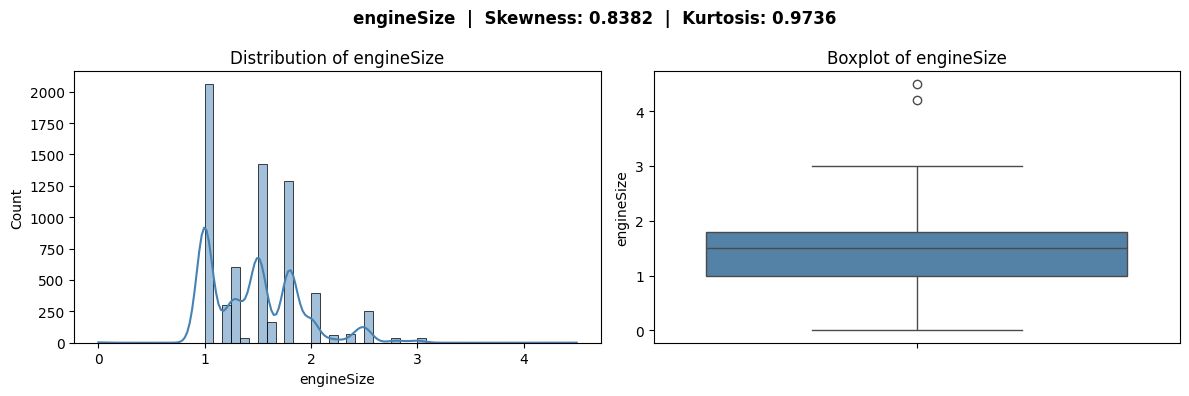

In [12]:
numerical_cols = df.select_dtypes(include='number').drop(columns='price').columns

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df[col], ax=axes[0], kde=True, color='steelblue')
    axes[0].set_title(f'Distribution of {col}')
    
    # Boxplot
    sns.boxplot(df[col], ax=axes[1], color='steelblue')
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.suptitle(f'{col}  |  Skewness: {df[col].skew():.4f}  |  Kurtosis: {df[col].kurt():.4f}', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 2.5. Categorical feature distribution

In [13]:
type(df.select_dtypes(include='object').columns)

pandas.core.indexes.base.Index

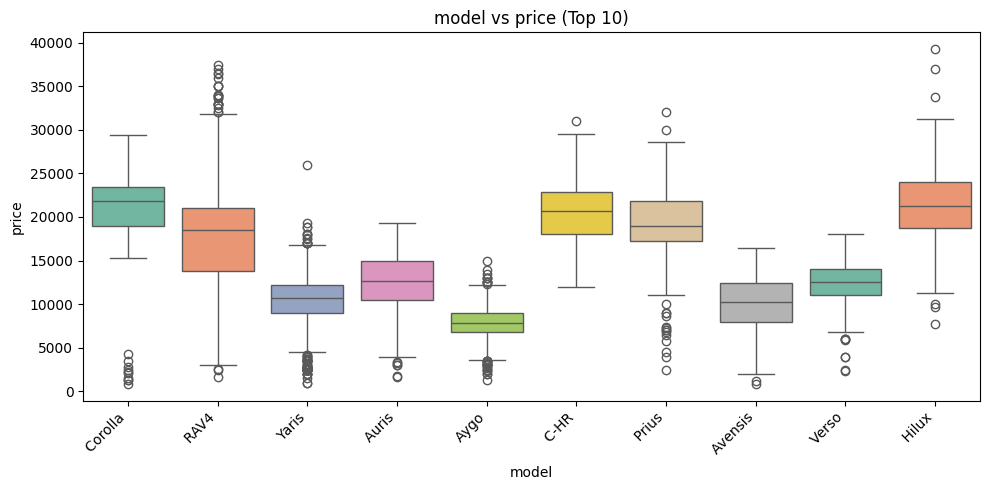

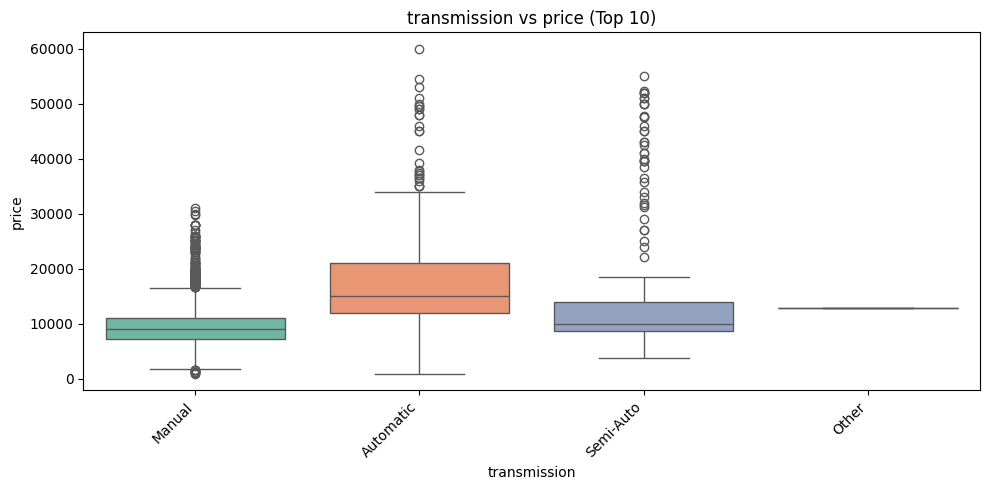

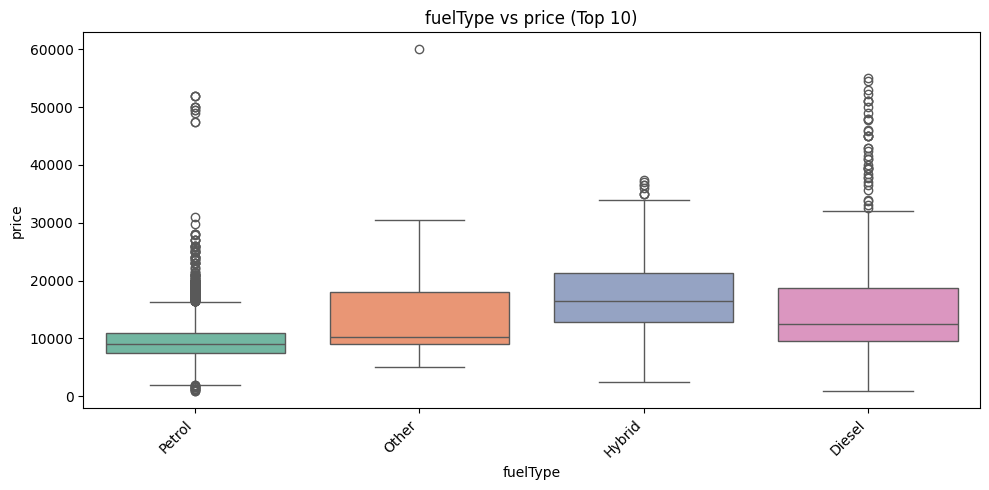

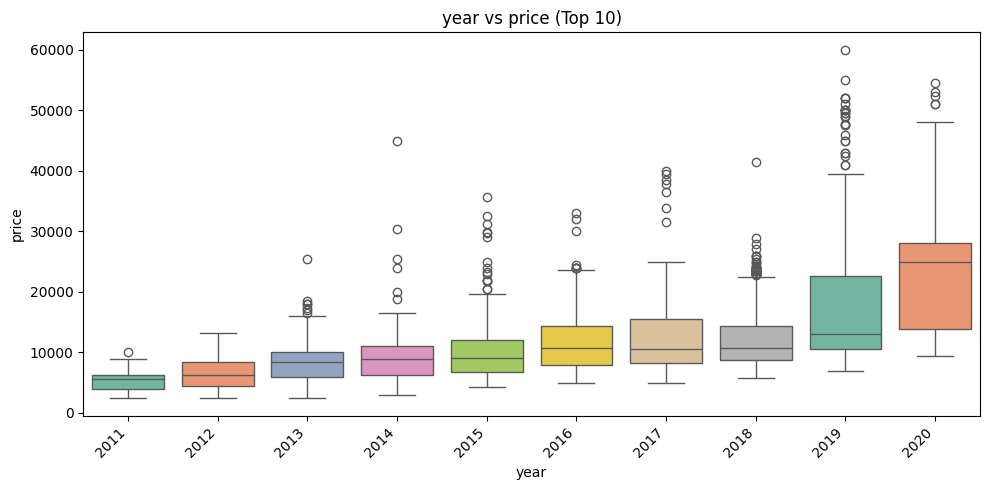

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

pseudo_categorical = ['year']
categorical_cols = df.select_dtypes(include='object').columns.tolist() + pseudo_categorical

for col in categorical_cols:
    top_n = df[col].value_counts().nlargest(10).index
    filtered = df[df[col].isin(top_n)]
    
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=filtered, x=col, y='price', hue=col, palette='Set2', legend=False)
    plt.title(f'{col} vs price (Top 10)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 2.6. Target range

In [15]:
print(f'Target range : from {df['price'].min()} to {df['price'].max()}')

Target range : from 850 to 59995


# 3. Initiate base model

## 3.1. Train-test-split

In [16]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

## 3.2. Label encoding

In [17]:
le = LabelEncoder()

categorical_cols = train_df.select_dtypes(include='object').columns

for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col]) 

## 3.3. Model building - Ridge Regression (linear model)

In [18]:
X_train = train_df.drop(columns=['price'])
y_train = train_df['price']

X_test = test_df.drop(columns=['price'])
y_test = test_df['price']

In [19]:
model_ridge = Ridge(alpha=1.0, random_state=42)

model_ridge.fit(X_train, y_train)

y_pred = model_ridge.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 3026.0223039586417
R2 Score: 0.7848304974932317


## 3.4. Model building - XGBoost (non-linear model)

In [20]:
X_train = train_df.drop(columns=['price'])
y_train = train_df['price']

X_test = test_df.drop(columns=['price'])
y_test = test_df['price']

In [21]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
 
y_pred = model.predict(X_test)
 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
 
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 1146.1574390108892
R2 Score: 0.96913081407547


# 4. `"Model"` feature optimization
Instead of using label encoding, let's implement target encoding on `model` feature.

## 4.1. Train-test-split

In [22]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42
)

## 4.2. Feature engineering - Target Encoding ("model" feature)

In [23]:
train_te = train_df.copy()
test_te = test_df.copy()

cat_cols = ['model']
target_col = 'price'

# global mean
global_mean = train_te[target_col].mean()

for col in cat_cols:
    
    # fill missing category with unknown
    train_te[col] = train_te[col].fillna('Unknown')
    test_te[col] = test_te[col].fillna('Unknown')
    
    # determine mean of each category
    target_means = train_te.groupby(col)[target_col].mean()
    
    # mapping
    train_te[col + '_te'] = train_te[col].map(target_means)
    test_te[col + '_te'] = test_te[col].map(target_means)
    
    # fallback
    train_te[col + '_te'] = train_te[col + '_te'].fillna(global_mean)
    test_te[col + '_te'] = test_te[col + '_te'].fillna(global_mean)

# drop original categorial feature
train_te = train_te.drop(columns=cat_cols)
test_te = test_te.drop(columns=cat_cols)

train_df = train_te
test_df = test_te

## 4.3. Feature engineering - Target Encoding (other feature)

In [24]:
le = LabelEncoder()

categorical_cols = train_df.select_dtypes(include='object').columns

for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col]) 

## 4.4. EDA - Correlation matrix on "Model" after Target Encoding

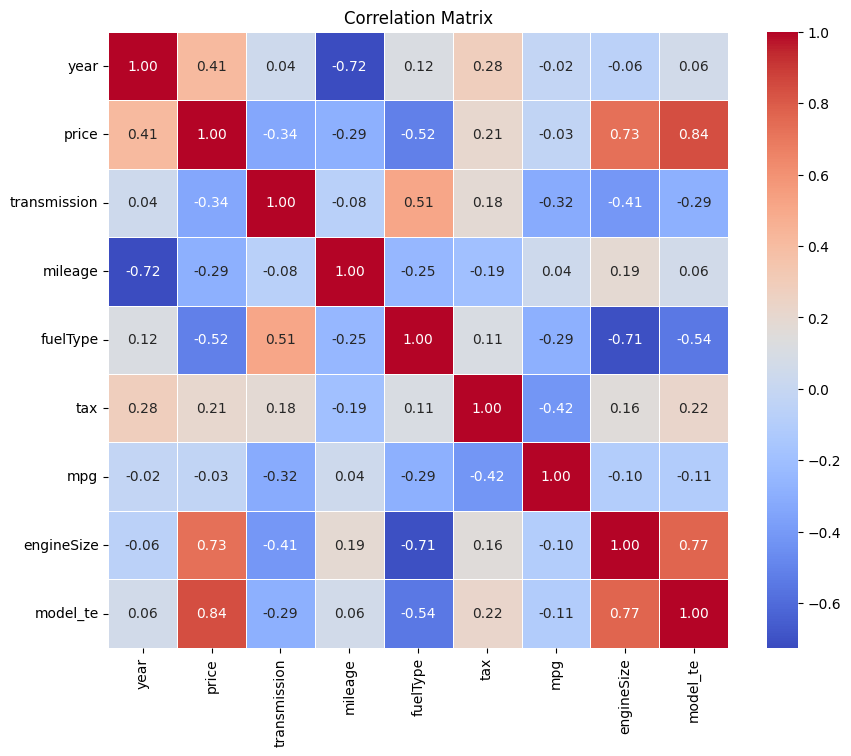

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

corr_matrix = train_df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

## 4.5. Model building - Ridge Regression (linear model)

In [26]:
X_train = train_df.drop(columns=['price'])
y_train = train_df['price']

X_test = test_df.drop(columns=['price'])
y_test = test_df['price']

In [27]:
model_ridge = Ridge(alpha=1.0, random_state=42)

model_ridge.fit(X_train, y_train)

y_pred = model_ridge.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 2060.084837216246
R2 Score: 0.9002743955260484


## 4.6. Model building - XGBoost (non-linear model)

In [28]:
X_train = train_df.drop(columns=['price'])
y_train = train_df['price']

X_test = test_df.drop(columns=['price'])
y_test = test_df['price']

In [29]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
 
y_pred = model.predict(X_test)
 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
 
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

RMSE: 1146.3537303118962
R2 Score: 0.9691202640533447


## 4.7. Evaluation

There is a significant improvement for the linear model (Ridge Regression), with R2 score increasing from 0.78 to 0.90.
However, the non-linear model (XGBoost), which already had the best R2 score, shows no significant improvement (~0.96).
Therefore, we are not keeping this process and the `"Model"` feature will remain using Label Encoding.